In [2]:
!pip install scikit-learn tensorflow matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------- ----------------- 4.5/8.1 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 20.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.6 MB 8.4 MB/s eta 0:00:05
   ---- ----------------------------------- 3.9/36.6 MB 9.4 MB/s eta 0:00:04
   ------ --------------------------------- 5.5/36.6 MB 8.8 MB/s eta 0:00:04
   -------- ------------------------------- 7.3/36.6 MB 8.7 MB/s eta 0:00:04
   ---------- ----------------------------- 9.2/36.6 MB 8.6 MB/s eta 0:00:04
   ------------ --------------------------- 11.3/36.6 MB 8.9 MB/s eta 0:00:03
   -------------- ------------------------- 13.6/36.6 MB 9.2 MB/s eta 0:00:03
   ---------------- ----------------------- 14.9/36.6 MB 8.9 MB/s eta 0:00:03
   ----------------- ---------------------- 16.3/36.6 MB 8.5 MB/s eta 0:00:03
   -------

In [3]:
# Import the dependencies:
from sklearn.datasets import make_blobs
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from matplotlib import pyplot

In [ ]:
# Use make_blobs from scikit-learn to generate a toy dataset with only two features and three label classes
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, 
    cluster_std=2, random_state=2)

In [5]:
# Use to_categorical from Keras to one-hot-encode the label:
y = to_categorical(y)

In [6]:
# Split the dataset into 80% training data and 20% test data. Note that we did not create a validation dataset in this example, for simplicity:
n_train = 800
train_X, test_X = X[:n_train, :], X[n_train:, :]
train_y, test_y = y[:n_train], y[n_train:]
print(train_X.shape, test_X.shape)

(800, 2) (200, 2)


In [ ]:
# Develop the model architecture—here, a very simple, two-layer MLP network (figure 4.11 shows the model summary):
model = Sequential()
model.add(Dense(25, input_dim=2, activation='relu'))
# Two input dimensions because we have two features. ReLU activation function for hidden layers.  
model.add(Dense(3, activation='softmax'))
# Softmax activation for the output layer with three nodes because we have three classes            
model.compile(loss='categorical_crossentropy', optimizer='adam', 
    metrics=['accuracy'])
# Cross-entropy loss function (explained in chapter 2) and adam optimizer (explained in the next section)
model.summary()

c:\Users\user\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            78 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the model for 1,000 epochs:
history = model.fit(train_X, train_y, validation_data=(test_X, test_y),
    epochs=1000, verbose=1)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4251 - loss: 0.9036 - val_accuracy: 0.6450 - val_loss: 0.7768
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5848 - loss: 0.8131 - val_accuracy: 0.7100 - val_loss: 0.7290
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6585 - loss: 0.7675 - val_accuracy: 0.7000 - val_loss: 0.6895
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6822 - loss: 0.7333 - val_accuracy: 0.7300 - val_loss: 0.6597
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6679 - loss: 0.7069 - val_accuracy: 0.7350 - val_loss: 0.6360
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6885 - loss: 0.6605 - val_accuracy: 0.7500 - val_loss: 0.6154
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6980 - loss: 0.6600 - val_accuracy: 0.7550 - val_loss: 0.5978
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7013 - loss: 0.6488 - val_accuracy: 0

In [9]:
# Evaluate the model:
_, train_acc = model.evaluate(train_X, train_y)
_, test_acc = model.evaluate(test_X, test_y)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - accuracy: 0.8195 - loss: 0.4041
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8245 - loss: 0.4072 
Train: 0.834, Test: 0.835


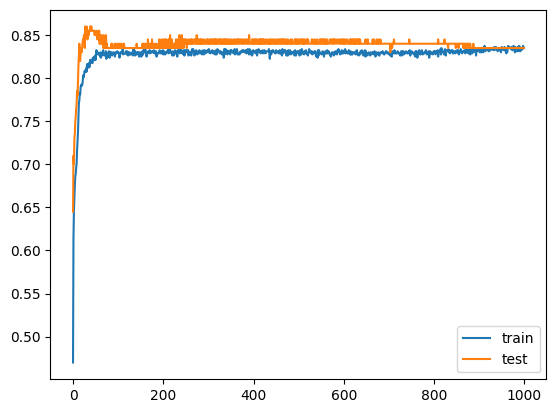

In [10]:
# Plot the learning curves of model accuracy (figure 4.12):
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()